# Блок 3 — машинное обучение

**Задача.** Предсказать, что клиент поставит низкую оценку (1–2 звезды),
используя только признаки, известные на момент вручения заказа. Сама витрина
и её словарь признаков — `sql/03_features.sql` и `FEATURES.md`.

**Что уже зафиксировано по итогам EDA (`notebooks/02_eda.ipynb`):**

* сильнейший фактор — опоздание относительно обещанной даты доставки;
* тестовый период — **июнь–август 2018** (18 520 заказов, 19,3 % витрины); он
  зафиксирован по времени, а не выбран случайно: так честнее, и на защите это
  аргумент.

**Что добавляется здесь, в `src/features.py`** (нельзя было сделать в SQL без
риска утечки):

* история продавца — доля негатива по прошлым заказам, посчитанная без утечки:
  только по заказам, оформленным раньше текущего;
* заполнение пропусков медианой по категории/по train — статистики считаются
  только на train и применяются к test как есть;
* топ-15 категорий + `other` — тот же порог, что и в EDA.

**Как воспроизвести:**

```
pip install -r requirements.txt
python src/build_db.py          # CSV -> db/olist.db
python src/build_features.py    # витрина order_features
```

Дальше — выполнить весь ноутбук (`Run All`). Графики сохраняются
в `reports/figures/` (файлы 11–15, продолжают нумерацию EDA).

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

# Тот же трюк, что и в 02_eda.ipynb: ноутбук запускается из notebooks/,
# а модуль с признаками лежит в src/.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import features as ft  # noqa: E402

FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42


def pc(value: float, digits: int = 1) -> str:
    """Число в процентах с запятой вместо точки — как в блоке EDA."""
    return f"{value:.{digits}f} %".replace(".", ",")


def save(fig, name: str) -> None:
    fig.savefig(FIG_DIR / name)
    print(f"Сохранено: reports/figures/{name}")


sns.set_theme(style="whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "savefig.dpi": 150,
        "savefig.bbox": "tight",
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "font.size": 10,
    }
)

BAD, OK, GREY = "#c0392b", "#2e86c1", "#95a5a6"

print("Готово: окружение настроено, features.py импортирован.")

Готово: окружение настроено, features.py импортирован.


In [2]:
train, test = ft.prepare_train_test()

summary = pd.DataFrame(
    [
        {
            "выборка": "train",
            "заказов": len(train),
            "период": f"{train.order_purchase_timestamp.min()[:7]} .. {train.order_purchase_timestamp.max()[:7]}",
            "доля негатива": pc(100 * train.target.mean()),
        },
        {
            "выборка": "test",
            "заказов": len(test),
            "период": f"{test.order_purchase_timestamp.min()[:7]} .. {test.order_purchase_timestamp.max()[:7]}",
            "доля негатива": pc(100 * test.target.mean()),
        },
    ]
)
summary

,выборка,заказов,период,доля негатива
0,train,77304,2016-09 .. 2018-05,"13,5 %"
1,test,18520,2018-06 .. 2018-08,"9,7 %"


**Вывод.** В train попали 77 304 заказа с сентября 2016 по май 2018,
в test — 18 520 заказов за июнь–август 2018, ровно 19,3 % витрины. Границу
разбиения заново не подбирали, взяли из решения, принятого в EDA.

Доля негатива в test (9,7 %) заметно ниже, чем в train (13,5 %). Это не шум
и не ошибка сборки: график `09_monthly_dynamics.png` из EDA уже показал, как
негатив снижается по мере того, как Olist в 2018 году наладил логистику.

Для модели отсюда два следствия. Первое: основная метрика проекта, ROC-AUC,
от доли классов не зависит, поэтому сдвиг базовой ставки сам по себе её
не искажает. Второе: такая проверка строже случайного разбиения, потому что модель
оценивается на периоде, где сигнал по опозданиям объективно слабее, чем
в обучении.

In [3]:
NUM = list(ft.NUMERIC_FEATURES)
CAT = list(ft.CATEGORICAL_FEATURES)

X_train, y_train = train[NUM + CAT], train["target"]
X_test, y_test = test[NUM + CAT], test["target"]

print(f"Признаков: {len(NUM)} числовых + {len(CAT)} категориальных = {len(NUM) + len(CAT)}")
print(f"train: X={X_train.shape}, test: X={X_test.shape}")
print(f"Пропусков в train: {X_train.isna().sum().sum()}, в test: {X_test.isna().sum().sum()}")

Признаков: 30 числовых + 6 категориальных = 36
train: X=(77304, 36), test: X=(18520, 36)
Пропусков в train: 0, в test: 0


Полный список признаков с описанием лежит в `FEATURES.md`. Поверх готовой
витрины мы добавили только историю продавца (`seller_negative_rate_prior`
и `seller_orders_prior`) и укрупнённую категорию `main_category_top`
(топ-15 плюс `other`). Оба расчёта живут в `src/features.py`.

`review_score` и все временные метки, кроме `purchase_*`, в набор признаков
не входят: они либо служат источником `target`, либо нужны только
для разбиения и своего сигнала не несут. Пропусков после
`features.prepare_train_test()` не осталось, это проверено выше.

## Подбор гиперпараметров: кросс-валидация на train

Итоговые метрики даёт только разбиение по времени. Стратифицированная
кросс-валидация нужна здесь для одного: подобрать гиперпараметры, ни разу
не заглянув в test до финальной оценки.

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lr_prep = ColumnTransformer(
    [("num", StandardScaler(), NUM), ("cat", OneHotEncoder(handle_unknown="ignore"), CAT)]
)
lr_pipe = Pipeline(
    [("prep", lr_prep), ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE))]
)

xgb_prep = ColumnTransformer(
    [("num", "passthrough", NUM), ("cat", OneHotEncoder(handle_unknown="ignore"), CAT)]
)
xgb_pipe = Pipeline(
    [
        (
            "prep",
            xgb_prep,
        ),
        (
            "clf",
            XGBClassifier(
                n_estimators=300,
                subsample=0.8,
                colsample_bytree=0.8,
                scale_pos_weight=ft.scale_pos_weight(y_train),
                eval_metric="auc",
                random_state=RANDOM_STATE,
                n_jobs=1,
            ),
        ),
    ]
)

t0 = time.time()
gs_lr = GridSearchCV(lr_pipe, {"clf__C": [0.01, 0.1, 1, 10]}, scoring="roc_auc", cv=cv, n_jobs=-1)
gs_lr.fit(X_train, y_train)
print(f"LogReg: лучший C={gs_lr.best_params_['clf__C']}, CV ROC-AUC={gs_lr.best_score_:.3f}  ({time.time() - t0:.0f} с)")

t0 = time.time()
gs_xgb = GridSearchCV(
    xgb_pipe,
    {"clf__max_depth": [3, 4, 6], "clf__learning_rate": [0.03, 0.05, 0.1]},
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
)
gs_xgb.fit(X_train, y_train)
print(f"XGBoost: лучшие параметры={gs_xgb.best_params_}, CV ROC-AUC={gs_xgb.best_score_:.3f}  ({time.time() - t0:.0f} с)")

LogReg: лучший C=0.01, CV ROC-AUC=0.769  (20 с)


XGBoost: лучшие параметры={'clf__learning_rate': 0.03, 'clf__max_depth': 4}, CV ROC-AUC=0.779  (91 с)


**Вывод.** CV ROC-AUC (0,769 у логистической регрессии и 0,779 у XGBoost)
заметно выше итоговых чисел на test, которые появятся ниже. Дело не в разной
доле негатива: ROC-AUC от неё не зависит. Кросс-валидация перемешивает заказы
одних и тех же месяцев, а test — новый период с другой логистической
обстановкой, и модель на нём проверяется строже. Сравнивать модели по этим
числам нельзя, они нужны только для выбора гиперпараметров. Модели сравниваем
дальше, на едином тестовом срезе.

In [5]:
dummy = DummyClassifier(strategy="prior").fit(X_train, y_train)
dummy_majority = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)

log_reg = gs_lr.best_estimator_
xgb_clf = gs_xgb.best_estimator_

print("Модели обучены на полном train с лучшими гиперпараметрами из CV.")

Модели обучены на полном train с лучшими гиперпараметрами из CV.


In [6]:
def evaluate(name, model, X, y):
    proba = model.predict_proba(X)[:, 1]
    top_n = int(round(len(y) * 0.05))
    top_idx = np.argsort(-proba)[:top_n]
    return {
        "модель": name,
        "ROC-AUC": roc_auc_score(y, proba),
        "precision@top-5 %": y.to_numpy()[top_idx].mean(),
    }


results = pd.DataFrame(
    [
        evaluate("DummyClassifier (baseline)", dummy, X_test, y_test),
        evaluate("Logistic Regression", log_reg, X_test, y_test),
        evaluate("XGBoost", xgb_clf, X_test, y_test),
    ]
).set_index("модель")
results_display = results.round(3)
results_display

,ROC-AUC,precision@top-5 %
модель,,
DummyClassifier (baseline),0.500,0.105
Logistic Regression,0.711,0.461
XGBoost,0.718,0.494


Сохранено: reports/figures/11_model_comparison.png


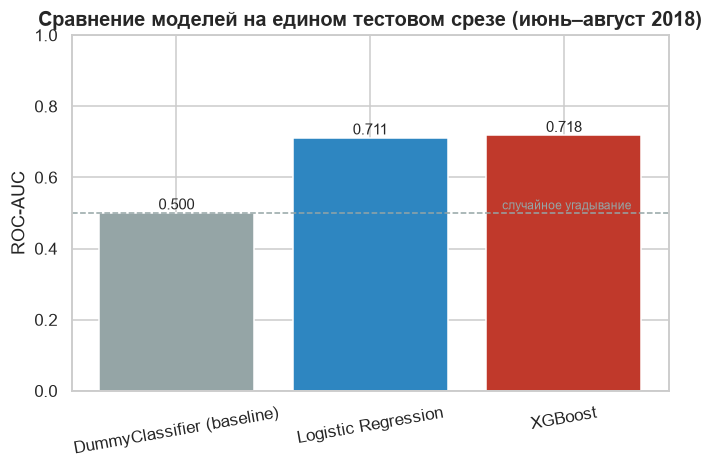

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.2))
colors = [GREY, OK, BAD]
bars = ax.bar(results.index, results["ROC-AUC"], color=colors)
for bar, value in zip(bars, results["ROC-AUC"]):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.01, f"{value:.3f}", ha="center", fontsize=10)
ax.axhline(0.5, color=GREY, linestyle="--", linewidth=1)
ax.text(2.35, 0.51, "случайное угадывание", color=GREY, fontsize=8, ha="right")
ax.set_ylabel("ROC-AUC")
ax.set_title("Сравнение моделей на едином тестовом срезе (июнь–август 2018)")
ax.set_ylim(0, 1)
plt.xticks(rotation=10)
save(fig, "11_model_comparison.png")
plt.show()

**Вывод.** `DummyClassifier` со стратегией `prior` выдаёт всем заказам одну
и ту же вероятность, долю негатива в train. Отличить негативный заказ
от позитивного он не может, поэтому его ROC-AUC ровно 0,5 — уровень
случайного угадывания. Это нулевая отметка, от которой считаем всё остальное.
Top-5 % для него — просто первые заказы по порядку, и precision в них (10,5 %)
держится на уровне доли негатива.

Логистическая регрессия даёт ROC-AUC 0,711, XGBoost — 0,718. По ROC-AUC модели
почти равны, и это ожидаемо: признаки в основном монотонные и слабо
взаимодействуют друг с другом, опоздание влияет почти линейно. На таких
задачах бустингу мало что добавить к линейной модели.

Разница заметнее там, где модель реально будут применять, — в верхушке списка.
ROC-AUC усредняет качество ранжирования по всем порогам, в том числе по тем,
где риском помечена половина заказов. Бизнес же работает только с первыми
процентами. Среди 5 % самых рискованных заказов доля реального негатива
у XGBoost 49,4 %, у логистической регрессии 46,1 %. Поэтому дальше работаем
с XGBoost, а логистическая регрессия остаётся интерпретируемой альтернативой
почти того же качества.

**Почему не accuracy.** Мажоритарный классификатор, который всегда отвечает
«негатива не будет», даёт на test 90,3 % accuracy. Это выше, чем у любой
обученной модели на разумном пороге, но при этом он не находит ни одного
реального негативного отзыва: recall равен нулю. Доля целевого класса в test
всего 9,7 %, поэтому accuracy почти целиком показывает, насколько хорошо
модель угадывает *мажоритарный* класс, а не то, ради чего модель строится.
Метрику мы зафиксировали заранее, это ROC-AUC: она оценивает, насколько
хорошо модель ранжирует заказы по риску, и не зависит от доли классов.
Accuracy в задаче не используется.

Сохранено: reports/figures/12_roc_curve.png


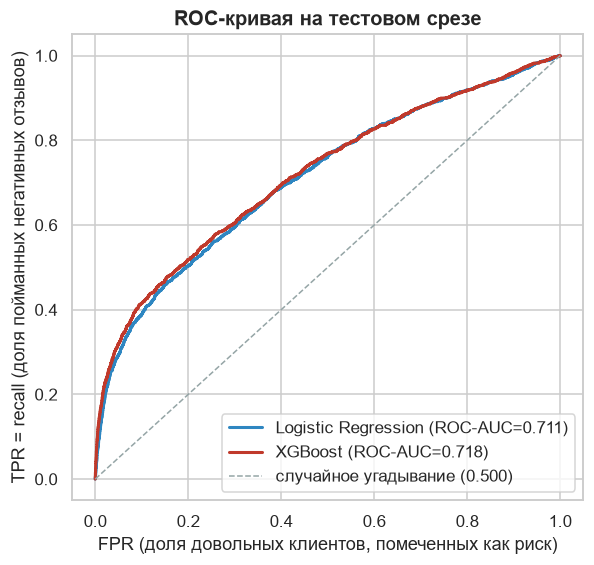

In [8]:
fig, ax = plt.subplots(figsize=(6, 5.5))

for name, model, color in [("Logistic Regression", log_reg, OK), ("XGBoost", xgb_clf, BAD)]:
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f"{name} (ROC-AUC={auc:.3f})", color=color, linewidth=2)

ax.plot([0, 1], [0, 1], color=GREY, linestyle="--", linewidth=1, label="случайное угадывание (0.500)")
ax.set_xlabel("FPR (доля довольных клиентов, помеченных как риск)")
ax.set_ylabel("TPR = recall (доля пойманных негативных отзывов)")
ax.set_title("ROC-кривая на тестовом срезе")
ax.legend(loc="lower right")
save(fig, "12_roc_curve.png")
plt.show()

**Вывод.** Обе модели идут заметно выше диагонали случайного угадывания
на всём диапазоне, но выигрыш распределён неравномерно.

В левой части графика, при малой доле ложных срабатываний, XGBoost немного,
но стабильно впереди: при FPR 2 % он ловит 22,1 % негатива против 18,7 %
у логистической регрессии. Здесь модель помечает только самые уверенные
случаи, и именно в этой зоне бизнесу важнее всего не тратить компенсации
впустую.

Дальше кривые сближаются, а начиная с FPR около 50 % почти совпадают. Ловить
весь негатив без разбора можно только ценой того, что риском будет помечена
большая часть довольных клиентов.

Отсюда практический вывод для следующего раздела: работать нужно
не с фиксированным порогом 0,5, а с top-K по вероятности.

In [9]:
test_span = pd.to_datetime(test.order_purchase_timestamp)
test_days = (test_span.max() - test_span.min()).days
orders_per_day = len(test) / test_days

proba_xgb = xgb_clf.predict_proba(X_test)[:, 1]
order = np.argsort(-proba_xgb)
y_sorted = y_test.to_numpy()[order]

rows = []
for k_pct in (0.02, 0.05, 0.10, 0.15, 0.20, 0.30):
    n = int(round(len(test) * k_pct))
    flagged = y_sorted[:n]
    rows.append(
        {
            "top-K": pc(100 * k_pct, 0),
            "заказов/день": round(n / test_days, 1),
            "precision": flagged.mean(),
            "recall": flagged.sum() / y_test.sum(),
        }
    )

topk = pd.DataFrame(rows).set_index("top-K")
topk_display = topk.round(3)
print(f"Тестовый период: {test_days} дней, в среднем {orders_per_day:.0f} заказов/день")
topk_display

Тестовый период: 89 дней, в среднем 208 заказов/день


,заказов/день,precision,recall
top-K,,,
2 %,4.2,0.654,0.134
5 %,10.4,0.494,0.254
10 %,20.8,0.355,0.365
15 %,31.2,0.284,0.438
20 %,41.6,0.237,0.488
30 %,62.4,0.189,0.584


Сохранено: reports/figures/13_precision_at_k.png


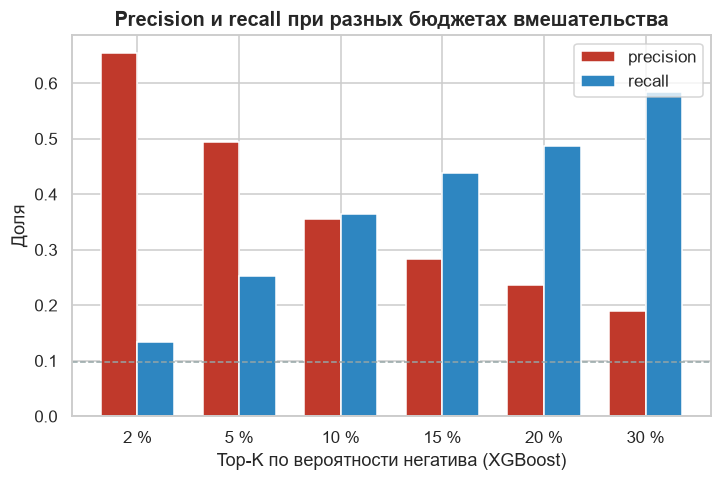

In [10]:
fig, ax1 = plt.subplots(figsize=(7.5, 4.5))
x = np.arange(len(topk))
ax1.bar(x - 0.18, topk["precision"], width=0.36, color=BAD, label="precision")
ax1.bar(x + 0.18, topk["recall"], width=0.36, color=OK, label="recall")
ax1.set_xticks(x)
ax1.set_xticklabels(topk.index)
ax1.set_xlabel("Top-K по вероятности негатива (XGBoost)")
ax1.set_ylabel("Доля")
ax1.axhline(y_test.mean(), color=GREY, linestyle="--", linewidth=1)
ax1.set_title("Precision и recall при разных бюджетах вмешательства")
ax1.legend(loc="upper right")
save(fig, "13_precision_at_k.png")
plt.show()

**Вывод и рекомендация бизнесу.** Порог решения выбирают не по значению 0,5,
а по пропускной способности команды, которая обзванивает клиентов
с компенсацией.

При бюджете top-5 % (около 10 заказов в день) точность выборки 49,4 %:
примерно каждый второй помеченный заказ действительно получит низкую оценку.
Поймать заранее при этом удастся 25,4 % всех будущих негативных отзывов.

Если расширить бюджет до top-15 % (около 31 заказа в день), recall вырастет
до 43,8 %, а precision упадёт до 28,4 %. Цена более широкого охвата
предсказуема и растёт плавно, без обрыва. Значит, решение упирается
в операционные мощности, а не в технический порог.

## Интерпретация

Сохранено: reports/figures/14_logreg_coefficients.png


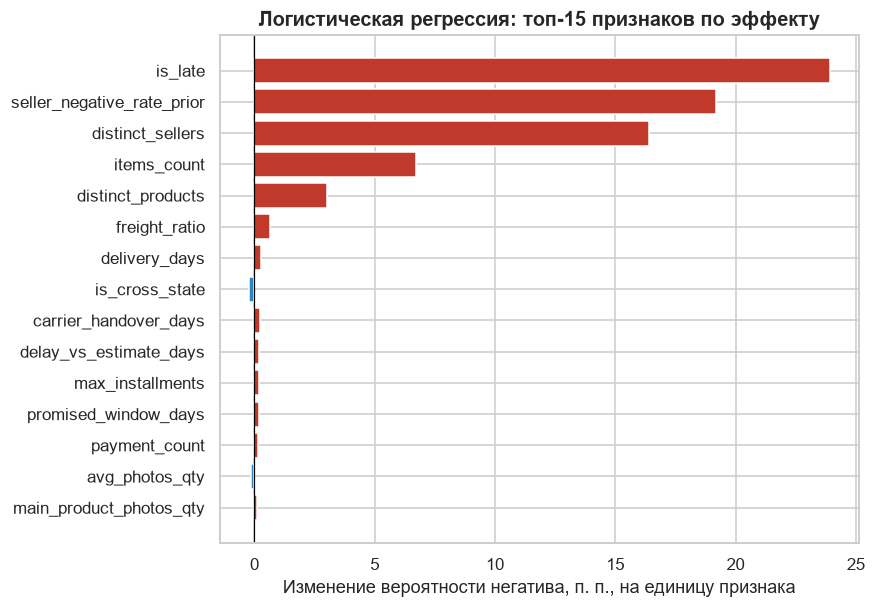

In [11]:
scaler = log_reg.named_steps["prep"].named_transformers_["num"]
coef = log_reg.named_steps["clf"].coef_[0]

# Коэффициент на масштабированном признаке → коэффициент на «сыром» признаке:
# x' = (x - mean) / std, поэтому вклад в log-odds на единицу x равен coef' / std.
num_coef_raw = pd.Series(coef[: len(NUM)] / scaler.scale_, index=NUM)

base_rate = y_train.mean()
marginal = base_rate * (1 - base_rate)  # dP/d(log-odds) в окрестности базовой ставки
effect_pp = (num_coef_raw * marginal * 100).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(7.5, 6))
top_effects = effect_pp.head(15).iloc[::-1]
colors = [BAD if v > 0 else OK for v in top_effects]
ax.barh(top_effects.index, top_effects.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Изменение вероятности негатива, п. п., на единицу признака")
ax.set_title("Логистическая регрессия: топ-15 признаков по эффекту")
save(fig, "14_logreg_coefficients.png")
plt.show()

**Вывод.** Коэффициенты логистической регрессии мы перевели из log-odds
на масштабированном признаке в понятные единицы: процентные пункты
вероятности негатива на единицу *сырого* признака, в окрестности базовой
ставки 13,5 %.

Главный результат подтверждает EDA. Сам факт опоздания (`is_late`) даёт скачок
на +23,9 п. п., это самый сильный единичный эффект в модели. Каждый отдельный
день просрочки весит куда меньше: `delay_vs_estimate_days` добавляет
+0,19 п. п. за день. Читается это так: клиент реагирует на несдержанное
обещание как на событие, а не пропорционально числу дней. Значит, вмешиваться
нужно у границы обещанной даты, а не по принципу «чем раньше, тем лучше»
при любом опоздании.

Заметны ещё два признака. `seller_negative_rate_prior` даёт +19,2 п. п.
на единицу доли, то есть столько разделяет продавца с историей 0 % и продавца
со 100 % негатива. `distinct_sellers` добавляет +16,4 п. п. за каждого
дополнительного продавца в заказе. Оба подтверждают исходные гипотезы: прошлая
репутация продавца переносится на новые заказы, а заказ, раздробленный между
несколькими продавцами, несёт дополнительный риск — разные сроки, разные
посылки.

permutation_importance: 13 с


Сохранено: reports/figures/15_permutation_importance.png


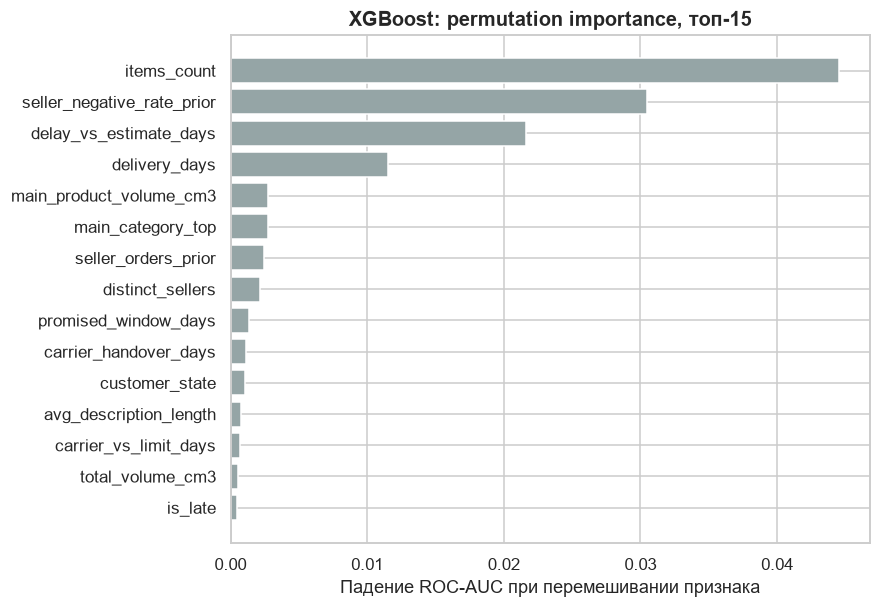

In [12]:
t0 = time.time()
perm = permutation_importance(
    xgb_clf, X_test, y_test, scoring="roc_auc", n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)
print(f"permutation_importance: {time.time() - t0:.0f} с")

perm_importance = pd.Series(perm.importances_mean, index=NUM + CAT).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7.5, 6))
top_perm = perm_importance.head(15).iloc[::-1]
ax.barh(top_perm.index, top_perm.values, color=GREY)
ax.set_xlabel("Падение ROC-AUC при перемешивании признака")
ax.set_title("XGBoost: permutation importance, топ-15")
save(fig, "15_permutation_importance.png")
plt.show()

**Вывод.** Permutation importance у XGBoost и коэффициенты логистической
регрессии сходятся в главном: сильнее всего работают `items_count`
и `seller_negative_rate_prior`, за ними `delay_vs_estimate_days`
и `delivery_days`. Все четыре признака — из групп, которые выделил ещё EDA:
состав заказа, история продавца и сроки доставки.

Расхождение в деталях ожидаемо. Линейная модель выделяет `is_late` отдельным
скачком, а бустинг выражает тот же нелинейный эффект сплитами
по `delay_vs_estimate_days` и в отдельном бинарном признаке не нуждается.
Поэтому у XGBoost `is_late` не попадает в топ, хотя обе модели видят одно
и то же явление.

## Итог и рекомендации бизнесу

**Сравнение моделей** (тестовый срез июнь–август 2018, единый для всех):

| Модель | ROC-AUC | Precision в top-5 % |
|---|---|---|
| DummyClassifier (нулевая отметка) | 0,500 | 10,5 % |
| Logistic Regression | 0,711 | 46,1 % |
| XGBoost | 0,718 | 49,4 % |

**Рекомендации:**

1. **Вмешиваться в тот момент, когда заказ пересекает обещанную дату
   доставки**, а не через фиксированное число дней после покупки. `is_late` —
   самый сильный отдельный фактор, и именно здесь имеет смысл автоматическое
   уведомление или компенсация, пока клиент ещё не оставил отзыв.
2. **Ограниченная команда компенсаций не повод отказываться от модели.**
   Порог решения задаётся как top-K по вероятности, а не как 0,5. Раздел
   precision@top-K выше даёт готовую таблицу «бюджет в заказах в день →
   ожидаемая точность и охват», её можно пересчитать под фактическую
   пропускную способность.
3. **История продавца работает**, но с оговоркой. Она посчитана без утечки,
   только по прошлым заказам. Однако у молодых продавцов история короткая
   (`seller_orders_prior` мал), и оценка по ней статистически неустойчива.
   Для них признак стоит брать осторожнее или заменять агрегатом
   по категории продавца.
4. **Раздробленные заказы, собранные у нескольких продавцов, добавляют риска**
   даже с поправкой на остальные признаки. Логистике стоит консолидировать
   отгрузку везде, где заказ можно собрать у одного продавца.

**Ограничения.** Метрики получены на единственном тестовом срезе по времени,
а не через k-fold на всём датасете. Это осознанный выбор: для задачи
с временным трендом такая проверка честнее случайного разбиения. Обратная
сторона — доверительный интервал оценки шире, чем дала бы кросс-валидация.
Признаки, зависящие от текста отзыва, исключены по правилу отсечки, поэтому
качество NLP-моделей по тексту отзыва мы не оценивали: это в задание
не входит.